In [1]:
import numpy as np
import pandas as pd
import sys, os

from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

from pyfrechet.metric_spaces import MetricData, Euclidean
from pyfrechet.regression.bagged_regressor import BaggedRegressor
from sklearn.preprocessing import MinMaxScaler
import multiprocessing as mp

import sys
sys.path.append(os.path.join(os.getcwd(), 'simulations_euc'))
import time

INFO: Using numpy backend


## Functions

In [2]:
def coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'y_data', 'OOB_quantile', 'forest', 'time'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results')):
        if file.endswith('.npy'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        start_time = time.time()
        oob_quantile = np.percentile(result['forest'].oob_errors(), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
        end_time = time.time()
        time_oob = end_time - start_time
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'sigma': file.split('_')[3][5:],
            'forest': [result['forest']],
            'OOB_quantile': [oob_quantile],
            'time': [result['tuning_fitting_time'] + time_oob],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size']=coverage_df['train_size'].astype('category')
    coverage_df['sigma'] = coverage_df.sigma.astype('category')
    return coverage_df


### SPLIT-CONFORMAL

def conf_coverage_results(M):
    """ Compute empirical quantiles for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'forest', 'residuals', 'time'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conformal_results')):
        if file.endswith('.npy'):
            i+=1
            print(i)
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conformal_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        sample_index = int(file.split('_')[1][4:])
        train_size = int(file.split('_')[2][1:])
        sigma = file.split('_')[3][5:]

        start_time = time.time()
        test_preds = result['forest'].predict(result['x_test_data'])
        quantile = np.percentile(M.d(result['y_test_data'], test_preds), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
        end_time = time.time()
        time_conf = end_time - start_time
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': sample_index,
            'train_size': train_size,
            'sigma': sigma,
            # 'x_train_data': [result['x_train_data']],
            # 'y_train_data': [result['y_train_data']],
            # 'x_test_data': [result['x_test_data']],
            # 'y_test_data': [result['y_test_data']],
            # 'test_predictions': [test_preds],
            'forest': [result['forest']],
            'quantiles': [quantile],
            'time': [result['tuning_fitting_time'] + time_conf],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df


# Function to simulate multivariate regression data
def simulate_data(sigma, X_design, betas):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a multivariate normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size)
    
    # Step 2: Apply the model transformations
    X_1 = X_design[:, 1]  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 2]  # X_2 corresponds to the second column
    X_3 = X_design[:, 3]  # X_3 corresponds to the third column
    X_4 = X_design[:, 4]  # X_4 corresponds to the fourth column
    X_5 = X_design[:, 5]  # X_5 corresponds to the fifth column

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*sin(pi*X_2) + beta_3*X_3^2 + beta_4*X_2*X_4 + beta_5*X_5 + epsilon
    sin_X2 = np.sin(np.pi * X_2)  # Apply sin to X_2
    X_3_squared = X_3 ** 2  # Apply square to X_3
    X_2_X_4 = X_2 * X_4  # Interaction term between X_2 and X_4

    Ys = betas[0] + betas[1] * X_1 + betas[2] * sin_X2 + betas[3] * X_3_squared + betas[4] * X_2_X_4 + betas[5] * X_5 + epsilon
            
    # Convert list to array for easier manipulation
    Ys = np.array(Ys).reshape(sample_size, 1)
    
    # Center the predictors
    #X_design -= X_design.mean(axis=0)
    
    # Center the responses
    #Ys -= Ys.mean(axis=0)
    
    return X_design[:,1:], Ys

### Read the data

Prediction balls

In [ ]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
betas = np.array([-1, -1, 2, -3, 3, -1])  # Define the true beta values
M = Euclidean(dim = 1)
# Load stored results
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')
coverage_df_euc=coverage_results()
coverage_df_euc.head()

0


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_10991/3748300860.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  coverage_df = pd.concat([coverage_df, pd.DataFrame({


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


Split_Conformal

In [ ]:
# Define confidence levels
np.random.seed(1000)
sign_level = [0.01, 0.05, 0.1]
# Load stored results
conformal_coverage_df=conf_coverage_results(M=M)
conformal_coverage_df.head()

In [3]:
# Define confidence levels
# import defs
# np.random.seed(1000)
# sign_level = np.array([0.01, 0.05, 0.1])
# betas = np.array([-1, -1, 2, -3, 3, -1])  # Define the true beta values
# M = Euclidean(dim=1)
# 
# 
# results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')
# files = os.listdir(results_dir)
# 
# if __name__ == '__main__':
#     with mp.Pool(processes=4) as pool:
#         dataframes = pool.starmap(defs.process_file, [(file, results_dir) for file in files])
# 
# coverage_df = pd.concat([df for df in dataframes if df is not None], ignore_index=True)
# coverage_df['train_size'] = coverage_df['train_size'].astype('category')
# coverage_df['sample_index'] = coverage_df['sample_index'].astype('category')
# coverage_df['sigma'] = coverage_df['sigma'].astype('category')

INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


196
33
17
6
23
305
21
50
84
133
433
411
4
12
11
424
496
250
421
175
254
272
84
242
496
170
175
496
228
3
469
103
103
403
484
111
133
421
392
128
260
14
159
479
4
62
320
337
67
353
269
59
193
172
260
470
124
325
393
392
380
196
69
421
65
159
325
315
394
200
428
386
195
59
85
46
315
351
459
258
69
218
35
317
364
82
169
169
307
309
22
400
130
143
205
169
354
241
390
253
327
195
412
95
130
276
241
487
68
22
87
299
95
30
157
395
422
122
436
400
445
230
7
406
12
263
122
243
187
106
112
352
148
30
487
112
100
430
12
271
271
196
228
383
221
152
430
334
495
207
403
239
478
355
379
48
78
433
326
274
107
174
148
376
401
304
472
2
64
343
48
434
452
304
226
373
399
98
448
209
227
383
316
290
391
188
8
498
178
334
90
490
319
78
56
248
371
302
88
222
8
281
448
178
72
53
88
210
361
373
296
488
5
441
160
438
47
169
343
188
486
224
341
465
134
409
351
155
465
186
138
373
131
446
329
55
329
460
483
327
434
244
477
55
45
36
177
319
138
447
206
310
8
393
281
165
161
319
155
147
236
99
293
206
112
254
329
3

KeyboardInterrupt: 

In [ ]:
# with mp.Pool(processes=8) as pool:
#     coverage_df_euc['OOB_errors'] = pool.map(defs.compute_oob_errors, [row for _, row in coverage_df_euc.iterrows()])
#     coverage_df_euc['OOB_quantile'] = pool.starmap(defs.compute_oob_quantile, [(row, sign_level) for _, row in coverage_df_euc.iterrows()])

# TYPE I

In [61]:
sigmas = np.array([0.1, 0.5, 1])

MC = 100
n_estimations = 10
n_predictors = 5

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario = {
    'sigma_0.1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
}

conf_diccionario = {
    'sigma_0.1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
}

In [68]:
# Obtain n_estimations estimations of Type I coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.1, 0.5, 1]:

    pb_coverage_df = coverage_df_euc[coverage_df_euc['sigma'] == str(sigma)]
    conf_coverage_df = conformal_coverage_df[conformal_coverage_df['sigma'] == str(sigma)]

    M = Euclidean(dim = 1)
    
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df[pb_coverage_df['train_size'] == N]
        conf_coverage_df_N = conf_coverage_df[conf_coverage_df['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            conf_yesno = np.zeros(3)
            # Randomly select rows from the dataframe
            new_X_design = np.random.uniform(0, 1, size = (MC, n_predictors))
            # Add a column of ones for the intercept (beta_0)
            new_X_design = np.c_[np.ones(MC), new_X_design]
            new_X_design, new_ys = simulate_data(sigma = sigma, X_design=new_X_design, betas=betas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            conf_lns = conf_coverage_df_N.sample(n=MC, replace=False)
    
            i = 0
            for j, pb_ln in pb_lns.iterrows():
                if j <= len(pb_lns):
                    conf_ln = conf_lns.iloc[j]
                else:
                    conf_ln = conf_lns.iloc[np.random.randint(0, len(conf_lns))]   
                # Generate one random point to test if it belongs to the CI_region
                new_X = new_X_design[i,:].reshape(1, n_predictors)

                #Predict the new observation
                pb_new_pred = pb_ln['forest'].predict(new_X)
                conf_new_pred = conf_ln['forest'].predict(new_X)

                new_y = new_ys[i]

                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, M.d(pb_new_pred, new_y) <= pb_ln['OOB_quantile']))
                conf_yesno = np.vstack((conf_yesno, M.d(conf_new_pred, new_y) <= conf_ln['quantiles']))

                i += 1

            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            conf_cov[estimation, :] = conf_yesno[1:,:].sum(axis=0) / MC
            
        pb_diccionario['sigma_'+str(sigma)][str(N)] = np.copy(pb_cov)
        
        conf_diccionario['sigma_'+str(sigma)][str(N)] = np.copy(conf_cov)

In [52]:
# import multiprocessing as mp
# import numpy as np
# 
# def compute_coverage_estimation(coverage_df_N, sigma, M, MC, n_predictors, betas):
#     cov = np.zeros((n_estimations, 3))
#     for estimation in range(n_estimations):
#         yesno = np.zeros(3)
#         new_X_design = np.random.uniform(0, 1, size=(MC, n_predictors))
#         new_X_design = np.c_[np.ones(MC), new_X_design]
#         new_X_design, new_ys = simulate_data(sigma=sigma, X_design=new_X_design, betas=betas)
#         lns = coverage_df_N.sample(n=MC, replace=False)
# 
#         for i, (_, ln) in enumerate(lns.iterrows()):
#             new_X = new_X_design[i, :].reshape(1, n_predictors)
#             new_pred = ln['forest'].predict(new_X)
#             new_y = new_ys[i]
#             yesno = np.vstack((yesno, M.d(new_pred, new_y) <= ln['OOB_quantile']))
#         
#         cov[estimation, :] = yesno[1:, :].sum(axis=0) / MC
#     return cov
# 
# def parallel_process(args):
#     return compute_coverage_estimation(*args)
# 
# M = Euclidean(dim=1)
# 
# for sigma in [1]:
#     coverage_df = coverage_df_euc[coverage_df_euc['sigma'] == str(sigma)]
# 
#     for N in [100, 200, 500]:
#         print(N)
#         coverage_df_N = coverage_df[coverage_df['train_size'] == N]
#         
#         # Updated pool.map call
#         with mp.Pool(processes = 2) as pool:
#             cov_results = pool.starmap(parallel_process, 
#                                        [(coverage_df_N, sigma, M, MC, n_predictors, betas) for _ in range(n_estimations)])
#                 
#         diccionario[f'sigma_{sigma}'][str(N)] = np.vstack(cov_results)

In [ ]:
for sigma in [0.1, 0.5, 1]:    
        for N in [50, 100, 200, 500]:
            print(f"sigma = {sigma}, N = {N}, mean of Type I coverage estimates: ", np.mean(pb_diccionario['sigma_'+str(sigma)][str(N)], axis = 0)) 
            print(f"sigma = {sigma}, N = {N}, standard deviation of Type I coverage estimates: ", np.sqrt(np.var(pb_diccionario['sigma_'+str(sigma)][str(N)], axis = 0))  )    

Prediction balls

In [ ]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.1, 0.5, 1]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

In [71]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error coverage for different distances, degrees of freedom and sample sizes', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_3162/2260981167.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [72]:
print(latex)

\begin{table}
\caption{Type I error coverage for different distances, degrees of freedom and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.1}} & \textbf{50} & 95.00 (0.00) & 90.00 (0.00) & 75.00 (0.00) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 100.00 (0.00) & 100.00 (0.00) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 90.00 (0.00) \\
\textbf{} & \textbf{500} & 95.00 (0.00) & 90.00 (0.00) & 90.00 (0.00) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.5}} & \textbf{50} & 100.00 (0.00) & 100.00 (0.00) & 100.00 (0.00) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 95.00 (0.00) & 90.00 (0.00) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 95.00 (0.00) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 95.00 (0.00) & 90.00 (0.00) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1}} & \textbf{50} & 100.00 (0.00) & 100.00 (0.00

SC

In [73]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.1, 0.5, 1]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(conf_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(conf_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
conf_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
conf_df

Significance Level           0.01           0.05            0.1
sigma N                                                        
0.1   50             90.00 (0.00)   90.00 (0.00)   85.00 (0.00)
      100           100.00 (0.00)   95.00 (0.00)   80.00 (0.00)
      200           100.00 (0.00)  100.00 (0.00)   90.00 (0.00)
      500            95.00 (0.00)   95.00 (0.00)   90.00 (0.00)
0.5   50            100.00 (0.00)  100.00 (0.00)  100.00 (0.00)
      100            95.00 (0.00)   95.00 (0.00)   80.00 (0.00)
      200           100.00 (0.00)  100.00 (0.00)   95.00 (0.00)
      500           100.00 (0.00)   85.00 (0.00)   85.00 (0.00)
1     50            100.00 (0.00)   90.00 (0.00)   90.00 (0.00)
      100           100.00 (0.00)   95.00 (0.00)   85.00 (0.00)
      200           100.00 (0.00)  100.00 (0.00)   95.00 (0.00)
      500           100.00 (0.00)   95.00 (0.00)   95.00 (0.00)

In [74]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
conf_df = conf_df.applymap(format_cell)

conf_latex = conf_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error coverage for different distances, degrees of freedom and sample sizes', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_3162/3790648141.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_df = conf_df.applymap(format_cell)


In [75]:
print(conf_latex)

\begin{table}
\caption{Type I error coverage for different distances, degrees of freedom and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.1}} & \textbf{50} & 90.00 (0.00) & 90.00 (0.00) & 85.00 (0.00) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 95.00 (0.00) & 80.00 (0.00) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 90.00 (0.00) \\
\textbf{} & \textbf{500} & 95.00 (0.00) & 95.00 (0.00) & 90.00 (0.00) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.5}} & \textbf{50} & 100.00 (0.00) & 100.00 (0.00) & 100.00 (0.00) \\
\textbf{} & \textbf{100} & 95.00 (0.00) & 95.00 (0.00) & 80.00 (0.00) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 95.00 (0.00) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 85.00 (0.00) & 85.00 (0.00) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1}} & \textbf{50} & 100.00 (0.00) & 90.00 (0.00) & 

# TYPE II

In [76]:
coverage_df_euc['II_coverage'] = [[0, 0, 0] for _ in range(len(coverage_df_euc))]
MC = 10

np.random.seed(1000)

#Calculate coverage for every dataset L_n (Type IV):
for i, ln in coverage_df_euc.iterrows():
    #Generate observations to estimate the probability
    new_X_design = np.random.uniform(size = (MC, n_predictors))
    new_X_design = np.c_[np.ones(MC), new_X_design]
    new_X, new_y = simulate_data(sigma = float(ln['sigma']), X_design=new_X_design, betas = betas)
    
    new_y = MetricData(M, np.array(new_y))

    new_pred = ln['forest'].predict(new_X)

    coverage_df_euc.at[i, 'II_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

In [7]:
conformal_coverage_df['II_coverage'] = [[0, 0, 0] for _ in range(len(conformal_coverage_df))]

#Calculate coverage for every dataset L_n (Type IV):
for i, ln in conformal_coverage_df.iterrows():
    #Generate observations to estimate the probability
    new_X_design = np.random.uniform(size = (MC, n_predictors))
    new_X_design = np.c_[np.ones(MC), new_X_design]
    new_X, new_y = simulate_data(sigma = float(ln['sigma']), X_design=new_X_design, betas = betas)
    
    new_y = MetricData(M, np.array(new_y))

    new_pred = ln['forest'].predict(new_X)

    conformal_coverage_df.at[i, 'II_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['quantiles'], (MC, 1)), axis = 0) / MC

NameError: name 'conformal_coverage_df' is not defined

In [ ]:
# Parallelizing Type IV coverage calculation
# def compute_type_II_coverage(ln, MC, n_predictors, betas, M):
#     new_X_design = np.random.uniform(size=(MC, n_predictors))
#     new_X_design = np.c_[np.ones(MC), new_X_design]
#     new_X, new_y = simulate_data(sigma=float(ln['sigma']), X_design=new_X_design, betas=betas)
#     new_y = MetricData(M, np.array(new_y))
#     new_pred = ln['forest'].predict(new_X)
#     return np.sum(M.d(new_pred, new_y).reshape(-1, 1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis=0) / MC
# 
# coverage_df_euc['II_coverage'] = [[0, 0, 0] for _ in range(len(coverage_df_euc))]
# np.random.seed(1000)
# 
# with mp.Pool(processes=8) as pool:
#     results = pool.starmap(compute_type_II_coverage, [(ln, MC, n_predictors, betas, M) for _, ln in coverage_df_euc.iterrows()])
# 
# for i, res in enumerate(results):
#     coverage_df_euc.at[i, 'II_coverage'] = res

In [178]:
ii_coverage_df_euc_alpha_01 = coverage_df_euc.copy()
ii_coverage_df_euc_alpha_05 = coverage_df_euc.copy()
ii_coverage_df_euc_alpha_1 = coverage_df_euc.copy()

ii_coverage_df_euc_alpha_01['II_coverage'] = coverage_df_euc['II_coverage'].apply(lambda x: x[0])
ii_coverage_df_euc_alpha_01['OOB_quantile'] = coverage_df_euc['OOB_quantile'].apply(lambda x: x[0])

ii_coverage_df_euc_alpha_05['II_coverage'] = coverage_df_euc['II_coverage'].apply(lambda x: x[1])
ii_coverage_df_euc_alpha_05['OOB_quantile'] = coverage_df_euc['OOB_quantile'].apply(lambda x: x[1])

ii_coverage_df_euc_alpha_1['II_coverage'] = coverage_df_euc['II_coverage'].apply(lambda x: x[2])
ii_coverage_df_euc_alpha_1['OOB_quantile'] = coverage_df_euc['OOB_quantile'].apply(lambda x: x[2])

ii_coverage_df_euc_alpha_01.head()
ii_coverage_df_euc_alpha_05.head()
ii_coverage_df_euc_alpha_1.head()

ii_coverage_df_conformal_alpha_01 = conformal_coverage_df.copy()
ii_coverage_df_conformal_alpha_05 = conformal_coverage_df.copy()
ii_coverage_df_conformal_alpha_1 = conformal_coverage_df.copy()

ii_coverage_df_conformal_alpha_01['II_coverage'] = conformal_coverage_df['II_coverage'].apply(lambda x: x[0])
ii_coverage_df_conformal_alpha_01['quantiles'] = conformal_coverage_df['quantiles'].apply(lambda x: x[0])

ii_coverage_df_conformal_alpha_05['II_coverage'] = conformal_coverage_df['II_coverage'].apply(lambda x: x[1])
ii_coverage_df_conformal_alpha_05['quantiles'] = conformal_coverage_df['quantiles'].apply(lambda x: x[1])

ii_coverage_df_conformal_alpha_1['II_coverage'] = conformal_coverage_df['II_coverage'].apply(lambda x: x[2])
ii_coverage_df_conformal_alpha_1['quantiles'] = conformal_coverage_df['quantiles'].apply(lambda x: x[2])

ii_coverage_df_conformal_alpha_01.head()
ii_coverage_df_conformal_alpha_05.head()
ii_coverage_df_conformal_alpha_1.head()

,sample_index,train_size,sigma,y_train_data,y_train_predictions,OOB_errors,OOB_quantile,forest,y_data,train_predictions,II_coverage
0,33,200,0.1,NaN,NaN,"[0.7997580135809848, 0.3531303349354359, 0.253...",1.147364,"BaggedRegressor(bootstrap_fraction=1, bootstra...","([-0.7830275267047787], [-0.5331329567272906],...","[[-0.27923347663698983], [-0.23400888546847287...",0.914
1,22,500,0.5,NaN,NaN,"[0.376494466655956, 0.26022590811976426, 0.393...",1.318110,"BaggedRegressor(bootstrap_fraction=1, bootstra...","([0.372905372607525], [0.16089068409459928], [...","[[0.09485333693790607], [-0.011299965973596037...",0.928
2,35,200,0.3,NaN,NaN,"[0.6400099129974459, 0.625789601503739, 0.1146...",1.157263,"BaggedRegressor(bootstrap_fraction=1, bootstra...","([0.8965614290494934], [1.6694281699786375], [...","[[0.4230082818269105], [1.1079658251575342], [...",0.906
3,30,100,0.5,NaN,NaN,"[0.4301245987400051, 0.6966139725042523, 0.592...",1.352314,"BaggedRegressor(bootstrap_fraction=1, bootstra...","([0.8967511189559944], [-1.5678711688138713], ...","[[0.4843179278198307], [-1.0205107456100768], ...",0.882
4,48,200,0.5,NaN,NaN,"[1.55756840582435, 0.44413321895343993, 0.5511...",1.401964,"BaggedRegressor(bootstrap_fraction=1, bootstra...","([2.7125509102007417], [0.860071103156419], [-...","[[1.4774188511121609], [0.5318636269799241], [...",0.934


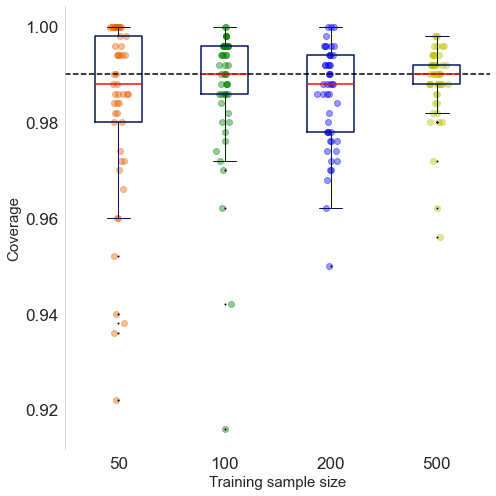

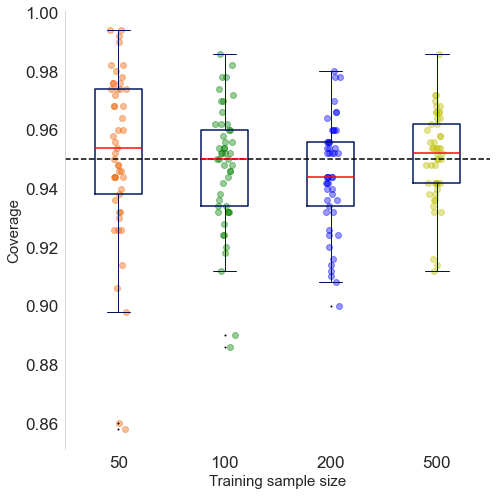

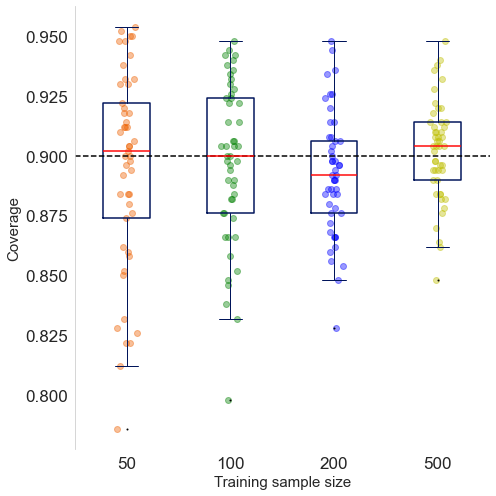

In [183]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_coverage_df_euc_alpha_01, ii_coverage_df_euc_alpha_05, ii_coverage_df_euc_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, tick_labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/euc_sigma_vs_II_coverage_' + str(alpha_level)[2:] + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

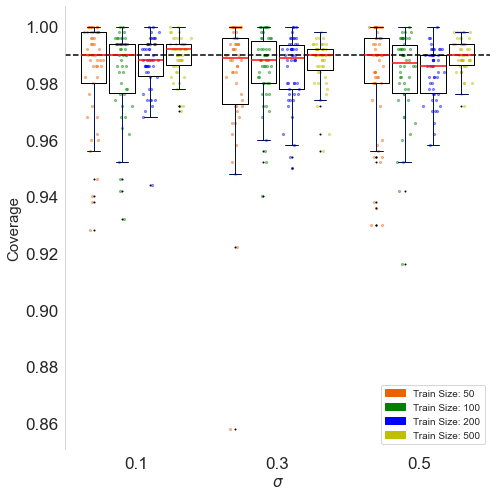

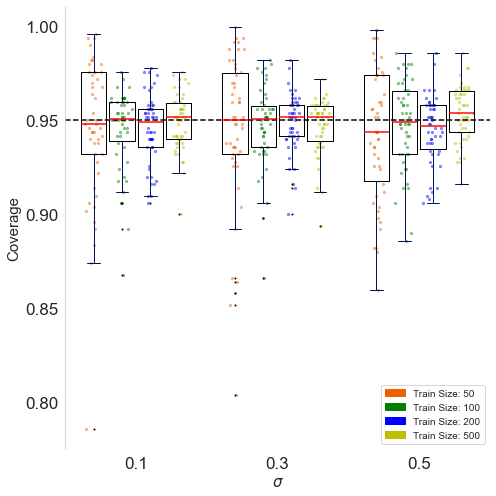

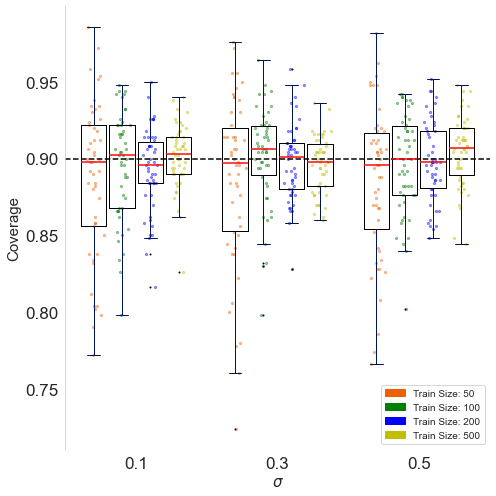

In [184]:
for data, alpha_level in zip(
    [ii_coverage_df_euc_alpha_01, ii_coverage_df_euc_alpha_05, ii_coverage_df_euc_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_coverage_df_euc_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_coverage_df_euc_alpha_05
    else:
        coverage_df = ii_coverage_df_euc_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    sigmas = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'II_coverage']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.axhline(y = 1 - alpha_level, color='black', linestyle='dashed', label=f'1 - $\\alpha$')
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(sigmas))],
        labels=sigmas
    )
    ax.tick_params(labelsize=17)
    ax.set_xlim(0, len(sigmas) * (len(train_sizes) + 1))
    ax.set_xlabel(r'$\sigma$', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='lower right')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/pb_euc_sigma_vs_II_coverage_' + str(alpha_level)[2:] + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

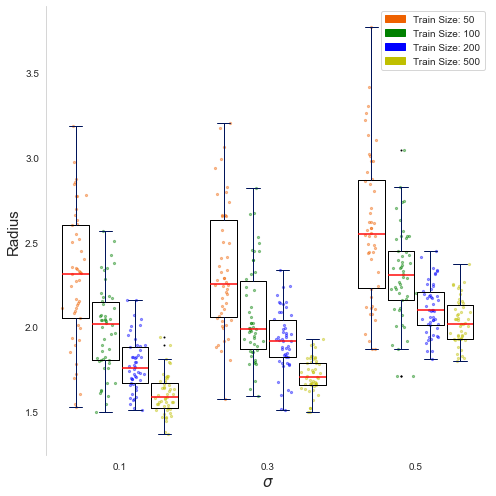

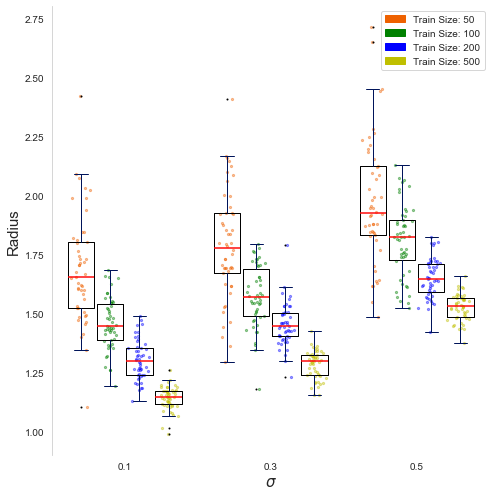

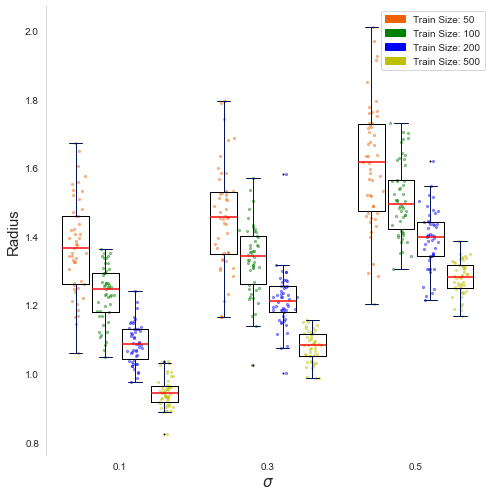

In [185]:
for data, alpha_level in zip(
    [ii_coverage_df_euc_alpha_01, ii_coverage_df_euc_alpha_05, ii_coverage_df_euc_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_coverage_df_euc_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_coverage_df_euc_alpha_05
    else:
        coverage_df = ii_coverage_df_euc_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    ax.set_xlabel(r'$\sigma$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/pb_euc_radius_vs_sigma_' + str(alpha_level)[2:] + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

In [ ]:
for data, alpha_level in zip(
    [ii_coverage_df_conformal_alpha_01, ii_coverage_df_conformal_alpha_05, ii_coverage_df_conformal_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_coverage_df_conformal_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_coverage_df_conformal_alpha_05
    else:
        coverage_df = ii_coverage_df_conformal_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'quantiles']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    ax.set_xlabel(r'$\sigma$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/conf_euc_radius_vs_sigma_' + str(alpha_level)[2:] + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [186]:
MC = 100
n_estimations = 1
n_predictors = 5

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'sigma_0.1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
}

conf_diccionario_iii = {
    'sigma_0.1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
}

# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.1, 0.5, 1]:
    pb_coverage_df = coverage_df_euc[coverage_df_euc['sigma'] == str(sigma)]
    conf_coverage_df = conformal_coverage_df[conformal_coverage_df['sigma'] == str(sigma)]
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = coverage_df[coverage_df['train_size'] == N]
        conf_coverage_df_N = conf_coverage_df[conf_coverage_df['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            conf_yesno = np.zeros(3)

            new_X_design = np.repeat(0.25, MC* n_predictors).reshape(MC, n_predictors)
            new_X_design = np.c_[np.ones(MC), new_X_design]
            new_Xs, new_ys = simulate_data(sigma = sigma, X_design = new_X_design, betas = betas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            conf_lns = conf_coverage_df_N.sample(n=MC, replace=False)

            i = 0
            for j, pb_ln in pb_lns.iterrows():
                conf_ln = conf_lns.iloc[j]
                # Retrieve the data           
                new_y = new_ys[i]
                pb_new_pred = pb_ln['forest'].predict(new_Xs[0].reshape(1, n_predictors))
                conf_new_pred = conf_ln['forest'].predict(new_Xs[0].reshape(1, n_predictors))
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, M.d(pb_new_pred, new_y) <= ln['OOB_quantile']))
                conf_yesno = np.vstack((conf_yesno, M.d(conf_new_pred, new_y) <= ln['quantiles']))

                i += 1
            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            conf_cov[estimation, :] = conf_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(pb_cov)
        conf_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(conf_cov)

In [188]:
for sigma in [0.1, 0.5, 1]:    
    for N in [50, 100, 200, 500]:
        print(f"sigma = {sigma}, N = {N}, mean of Type III coverage estimates: ", np.mean(pb_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0)) 
        print(f"sigma = {sigma}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(pb_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0))  )   

sigma = 0.1, N = 50, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 50, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 100, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 200, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 200, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 500, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 500, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 50, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.3, N = 50, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 100, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.3, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 200, mean of Type III coverage estimates:  [1.     

In [118]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.1, 0.5, 1]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
pb_df_iii

Significance Level           0.01           0.05           0.1
sigma N                                                       
0.1   50             99.43 (0.92)   99.18 (1.00)  97.88 (0.40)
      100           100.00 (0.00)  100.00 (0.00)  99.18 (1.15)
      200           100.00 (0.00)  100.00 (0.00)  99.02 (1.17)
      500           100.00 (0.00)  100.00 (0.00)  99.92 (0.40)
0.3   50             99.84 (0.55)   99.18 (1.29)  96.90 (1.84)
      100           100.00 (0.00)   99.43 (1.08)  96.73 (3.11)
      200           100.00 (0.00)   99.67 (0.75)  96.08 (3.10)
      500           100.00 (0.00)   99.35 (1.25)  96.16 (2.79)
0.5   50             98.20 (1.76)   94.94 (3.01)  90.29 (3.88)
      100            99.76 (0.66)   96.73 (2.52)  91.51 (3.45)
      200            99.76 (0.66)   97.14 (2.45)  93.14 (3.60)
      500            99.76 (0.66)   96.98 (2.65)  91.76 (3.81)

In [120]:
# Apply formatting to all cells
pb_df_iii= pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(pb_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.1}} & \textbf{50} & 99.43 (0.92) & 99.18 (1.00) & 97.88 (0.40) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 100.00 (0.00) & 99.18 (1.15) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 99.02 (1.17) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 100.00 (0.00) & 99.92 (0.40) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.3}} & \textbf{50} & 99.84 (0.55) & 99.18 (1.29) & 96.90 (1.84) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 99.43 (1.08) & 96.73 (3.11) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 99.67 (0.75) & 96.08 (3.10) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 99.35 (1.25) & 96.16 (2.79) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.5}} & \textbf{50} & 98.20 (1.76) & 94.94 (3.01) & 90.29 (3.88

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/2281014583.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_iii= df_iii.applymap(format_cell)


In [ ]:
for sigma in [0.1, 0.5, 1]:    
    for N in [50, 100, 200, 500]:
        print(f"sigma = {sigma}, N = {N}, mean of Type III coverage estimates: ", np.mean(conf_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0)) 
        print(f"sigma = {sigma}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(conf_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0))  )   

sigma = 0.1, N = 50, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 50, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 100, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 200, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 200, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 500, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 500, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 50, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.3, N = 50, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 100, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.3, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 200, mean of Type III coverage estimates:  [1.     

In [ ]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.1, 0.5, 1]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
conf_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
conf_df_iii

Significance Level           0.01           0.05           0.1
sigma N                                                       
0.1   50             99.43 (0.92)   99.18 (1.00)  97.88 (0.40)
      100           100.00 (0.00)  100.00 (0.00)  99.18 (1.15)
      200           100.00 (0.00)  100.00 (0.00)  99.02 (1.17)
      500           100.00 (0.00)  100.00 (0.00)  99.92 (0.40)
0.3   50             99.84 (0.55)   99.18 (1.29)  96.90 (1.84)
      100           100.00 (0.00)   99.43 (1.08)  96.73 (3.11)
      200           100.00 (0.00)   99.67 (0.75)  96.08 (3.10)
      500           100.00 (0.00)   99.35 (1.25)  96.16 (2.79)
0.5   50             98.20 (1.76)   94.94 (3.01)  90.29 (3.88)
      100            99.76 (0.66)   96.73 (2.52)  91.51 (3.45)
      200            99.76 (0.66)   97.14 (2.45)  93.14 (3.60)
      500            99.76 (0.66)   96.98 (2.65)  91.76 (3.81)

In [ ]:
# Apply formatting to all cells
conf_df_iii= pb_df_iii.applymap(format_cell)

conf_latex_iii = conf_df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for different values of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(conf_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.1}} & \textbf{50} & 99.43 (0.92) & 99.18 (1.00) & 97.88 (0.40) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 100.00 (0.00) & 99.18 (1.15) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 99.02 (1.17) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 100.00 (0.00) & 99.92 (0.40) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.3}} & \textbf{50} & 99.84 (0.55) & 99.18 (1.29) & 96.90 (1.84) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 99.43 (1.08) & 96.73 (3.11) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 99.67 (0.75) & 96.08 (3.10) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 99.35 (1.25) & 96.16 (2.79) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.5}} & \textbf{50} & 98.20 (1.76) & 94.94 (3.01) & 90.29 (3.88

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/2281014583.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_iii= df_iii.applymap(format_cell)


# Type IV

In [100]:
np.random.seed(1000)
coverage_df_euc['IV_coverage'] = [[0, 0, 0] for _ in range(len(coverage_df_euc))]
n_predictors = 5
MC = 100
for i, ln in coverage_df_euc.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    sigma = float(ln['sigma'])
    new_pred = np.array([ln['forest'].predict(np.repeat(0.25, n_predictors).reshape(1, n_predictors))])
    new_pred = MetricData(M, np.tile(new_pred, (MC, 1)))
    new_y = MetricData(M, simulate_data(X_design = np.c_[np.ones(MC), np.repeat(0.25, MC * n_predictors).reshape(MC, n_predictors)], sigma = sigma, betas = betas)[1])
    coverage_df_euc.at[i, 'IV_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

In [ ]:
np.random.seed(1000)
conformal_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(conformal_coverage_df))]
n_predictors = 5
MC = 100
for i, ln in conformal_coverage_df.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    sigma = float(ln['sigma'])
    new_pred = np.array([ln['forest'].predict(np.repeat(0.25, n_predictors).reshape(1, n_predictors))])
    new_pred = MetricData(M, np.tile(new_pred, (MC, 1)))
    new_y = MetricData(M, simulate_data(X_design = np.c_[np.ones(MC), np.repeat(0.25, MC * n_predictors).reshape(MC, n_predictors)], sigma = sigma, betas = betas)[1])
    conformal_coverage_df.at[i, 'IV_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['quantiles'], (MC, 1)), axis = 0) / MC

In [101]:
iv_coverage_df_euc_alpha_01 = coverage_df_euc.copy()
iv_coverage_df_euc_alpha_05 = coverage_df_euc.copy()
iv_coverage_df_euc_alpha_1 = coverage_df_euc.copy()

iv_coverage_df_euc_alpha_01['IV_coverage'] = coverage_df_euc['IV_coverage'].apply(lambda x: x[0])
iv_coverage_df_euc_alpha_05['IV_coverage'] = coverage_df_euc['IV_coverage'].apply(lambda x: x[1])
iv_coverage_df_euc_alpha_1['IV_coverage'] = coverage_df_euc['IV_coverage'].apply(lambda x: x[2])

iv_coverage_df_euc_alpha_01.head()
iv_coverage_df_euc_alpha_05.head()
iv_coverage_df_euc_alpha_1.head()

iv_coverage_df_conf_alpha_01 = conformal_coverage_df.copy()
iv_coverage_df_conf_alpha_05 = conformal_coverage_df.copy()
iv_coverage_df_conf_alpha_1 = conformal_coverage_df.copy()

iv_coverage_df_conf_alpha_01['IV_coverage'] = conformal_coverage_df['IV_coverage'].apply(lambda x: x[0])
iv_coverage_df_conf_alpha_05['IV_coverage'] = conformal_coverage_df['IV_coverage'].apply(lambda x: x[1])
iv_coverage_df_conf_alpha_1['IV_coverage'] = conformal_coverage_df['IV_coverage'].apply(lambda x: x[2])

iv_coverage_df_conf_alpha_01.head()
iv_coverage_df_conf_alpha_05.head()
iv_coverage_df_conf_alpha_1.head()

,sample_index,train_size,sigma,x_train_data,y_train_data,train_predictions,x_test_data,y_test_data,test_predictions,residuals,forest,quantiles,II_coverage,IV_coverage
0,33,200,0.1,"[[0.7395884793432653, 0.6693394334136951, 0.06...","([2.149990142208994], [1.088787413191077], [1....",NaN,"[[0.3265947852187776, 0.5482745989941231, 0.36...","([1.5032662082600579], [-0.685633088950402], [...","([0.7747193340445571], [-0.5147280807310177], ...","[0.7285468742155008, 0.17090500821938426, 0.47...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.4698726595348766, 1.319394723884617, 1.1598...","[0.99, 0.918, 0.882]",1.000
1,22,500,0.5,"[[0.7660747330386279, 0.874842241692091, 0.715...","([-0.9546853799100476], [-1.5038033989758028],...",NaN,"[[0.014901792994685754, 0.3680643632410456, 0....","([1.8635527910596643], [-0.03531888281596868],...","([0.7830309697581318], [-0.5575395915372015], ...","[1.0805218213015326, 0.5222207087212327, 1.071...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.2499577447425714, 1.704329340802661, 1.3685...","[0.992, 0.958, 0.916]",0.990
2,35,200,0.3,"[[0.6889950251636495, 0.06795633566665091, 0.4...","([-1.1311610552365545], [-1.004213479669268], ...",NaN,"[[0.8612893428945011, 0.099370374155555, 0.984...","([-2.9287850366880273], [-1.323383707051214], ...","([-1.300342321673621], [-1.2396716215631227], ...","[1.6284427150144063, 0.08371208548809128, 1.14...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.076720287935, 1.8377846994996054, 1.4992635...","[0.988, 0.968, 0.938]",1.000
3,30,100,0.5,"[[0.9186403928008772, 0.150405719539191, 0.169...","([0.12064455029281457], [-2.5138788161501795],...",NaN,"[[0.317510905741294, 0.2923793983138011, 0.841...","([-1.3193826162953903], [-0.6228819724094027],...","([-0.8617321952939014], [-0.8027907996889487],...","[0.4576504210014889, 0.17990882727954605, 0.22...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.3008857545262105, 1.5972952473640556, 1.370...","[0.99, 0.912, 0.862]",0.988
4,48,200,0.5,"[[0.2625807623174815, 0.016217438531158528, 0....","([-1.0369588585485137], [-0.4096651445222883],...",NaN,"[[0.00779988832449378, 0.4128882202286176, 0.2...","([0.904431429765673], [1.6442614848443613], [-...","([0.6130661389149838], [0.9298157890020337], [...","[0.2913652908506892, 0.7144456958423276, 1.670...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.2793471972043755, 1.6704529443179676, 1.362...","[0.992, 0.952, 0.896]",0.990


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/3078901257.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


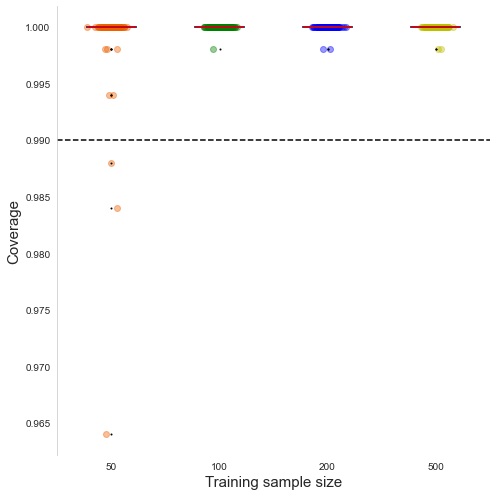

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/3078901257.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


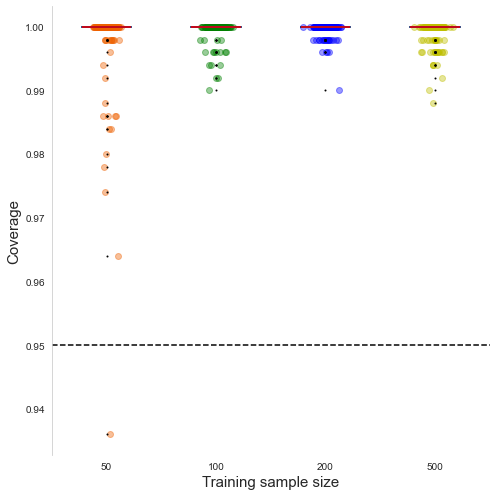

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/3078901257.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


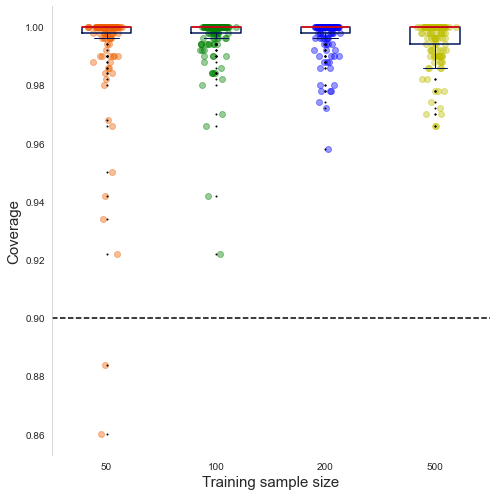

In [110]:
# Plot coverages vs. training sample size

##### Set style options here #####
sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1,
                  linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([iv_coverage_df_euc_alpha_01, iv_coverage_df_euc_alpha_05, iv_coverage_df_euc_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['IV_coverage'].values,
        '100': data_100['IV_coverage'].values,
        '200': data_200['IV_coverage'].values,
        '500': data_500['IV_coverage'].values
    })

    #sns.boxplot(data = data, x='train_size', y='IV_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})
    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.06, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    ax.set_xlabel('Training sample size', fontsize=15)
    ax.set_ylabel('Coverage', fontsize=15)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/pb_euc_N_vs_IV_coverage_' + str(alpha_level)[2:] + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()